In [1]:
from QiskitTranspiler.transpiler.passes.layout.layout import Layout
from qiskit import QuantumCircuit
from qiskit.providers.fake_provider import GenericBackendV2
from qiskit_aer import AerSimulator
from QiskitTranspiler.transpiler.passes.translation.translator import translate_circuit
from qiskit.converters import circuit_to_dag, dag_to_circuit
from QiskitTranspiler.transpiler.transpile import transpile

16


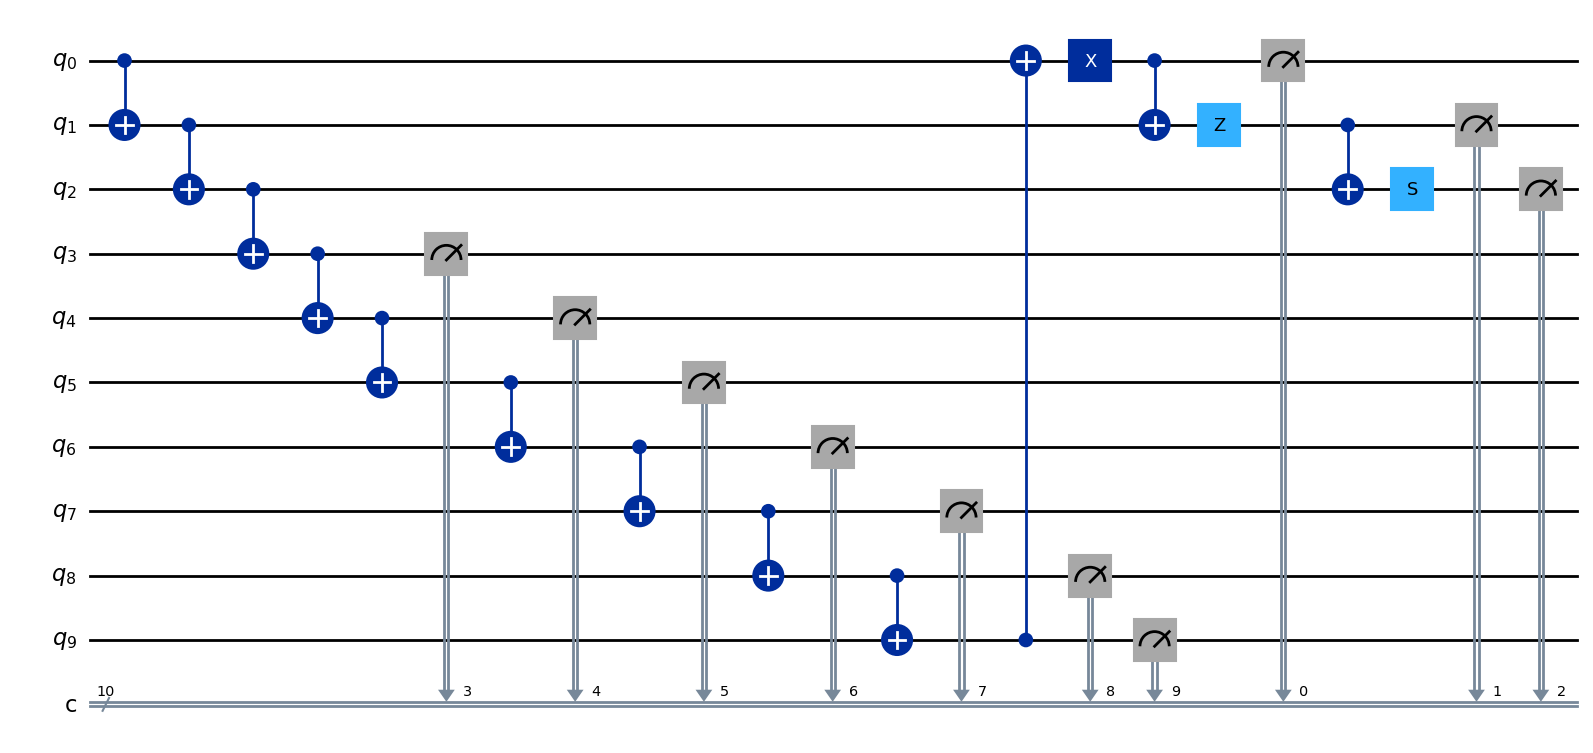

In [2]:
qc = QuantumCircuit(10, 10)
qc.cx(0, 1)
qc.cx(1, 2)
qc.cx(2, 3)
qc.cx(3, 4)
qc.cx(4, 5)
qc.cx(5, 6)
qc.cx(6, 7)
qc.cx(7, 8)
qc.cx(8, 9)
qc.cx(9, 0)
qc.x(0)
qc.cx(0, 1)
qc.z(1)
qc.cx(1, 2)
qc.s(2)
qc.measure([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], [0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
print(qc.depth())
qc.draw("mpl")

# Simulated Hardware
## Run the circuit 50 times with the custom transpiler and then with the Qiskit transpiler

In [3]:
from qiskit_ibm_runtime.fake_provider import FakeFez, FakeTorino, FakeMarrakesh, FakePerth
from qiskit_ibm_runtime import SamplerV2 as Sampler

#Testing first with a simulator, then with a real backend
backend = FakeFez()

from QiskitTranspiler.transpiler.transpile import transpile

transpiled_circuit = transpile(qc, backend)

[BasisTranslator] Warning: Found a built-in equivalence table that covers the provided custom_basis. Using 'heron'


In [6]:
sampler = Sampler(mode=backend)

experiment_errors = []

for _ in range(50):
    job = sampler.run([transpiled_circuit], shots=1024)
    counts = job.result()[0].join_data().get_counts()

    acc_sum = 0
    for state, count in counts.items():
        if state != "0000000111":
            acc_sum += count
    error = acc_sum / 1024
    experiment_errors.append(error)

print("Average error over 50 runs (Qiskit transpiler):", sum(experiment_errors) / len(experiment_errors))
print("Errors for each run:", experiment_errors)

Average error over 50 runs (Qiskit transpiler): 0.1653515625
Errors for each run: [0.1796875, 0.1611328125, 0.1513671875, 0.1552734375, 0.1357421875, 0.16015625, 0.1572265625, 0.171875, 0.1767578125, 0.173828125, 0.1611328125, 0.150390625, 0.1552734375, 0.166015625, 0.181640625, 0.1728515625, 0.14453125, 0.15234375, 0.1474609375, 0.17578125, 0.1796875, 0.1748046875, 0.16015625, 0.166015625, 0.1533203125, 0.1650390625, 0.181640625, 0.1484375, 0.1796875, 0.181640625, 0.1796875, 0.1806640625, 0.15625, 0.1748046875, 0.1630859375, 0.1767578125, 0.1884765625, 0.16015625, 0.177734375, 0.173828125, 0.1572265625, 0.1513671875, 0.1533203125, 0.1748046875, 0.181640625, 0.1484375, 0.15234375, 0.16796875, 0.16796875, 0.16015625]


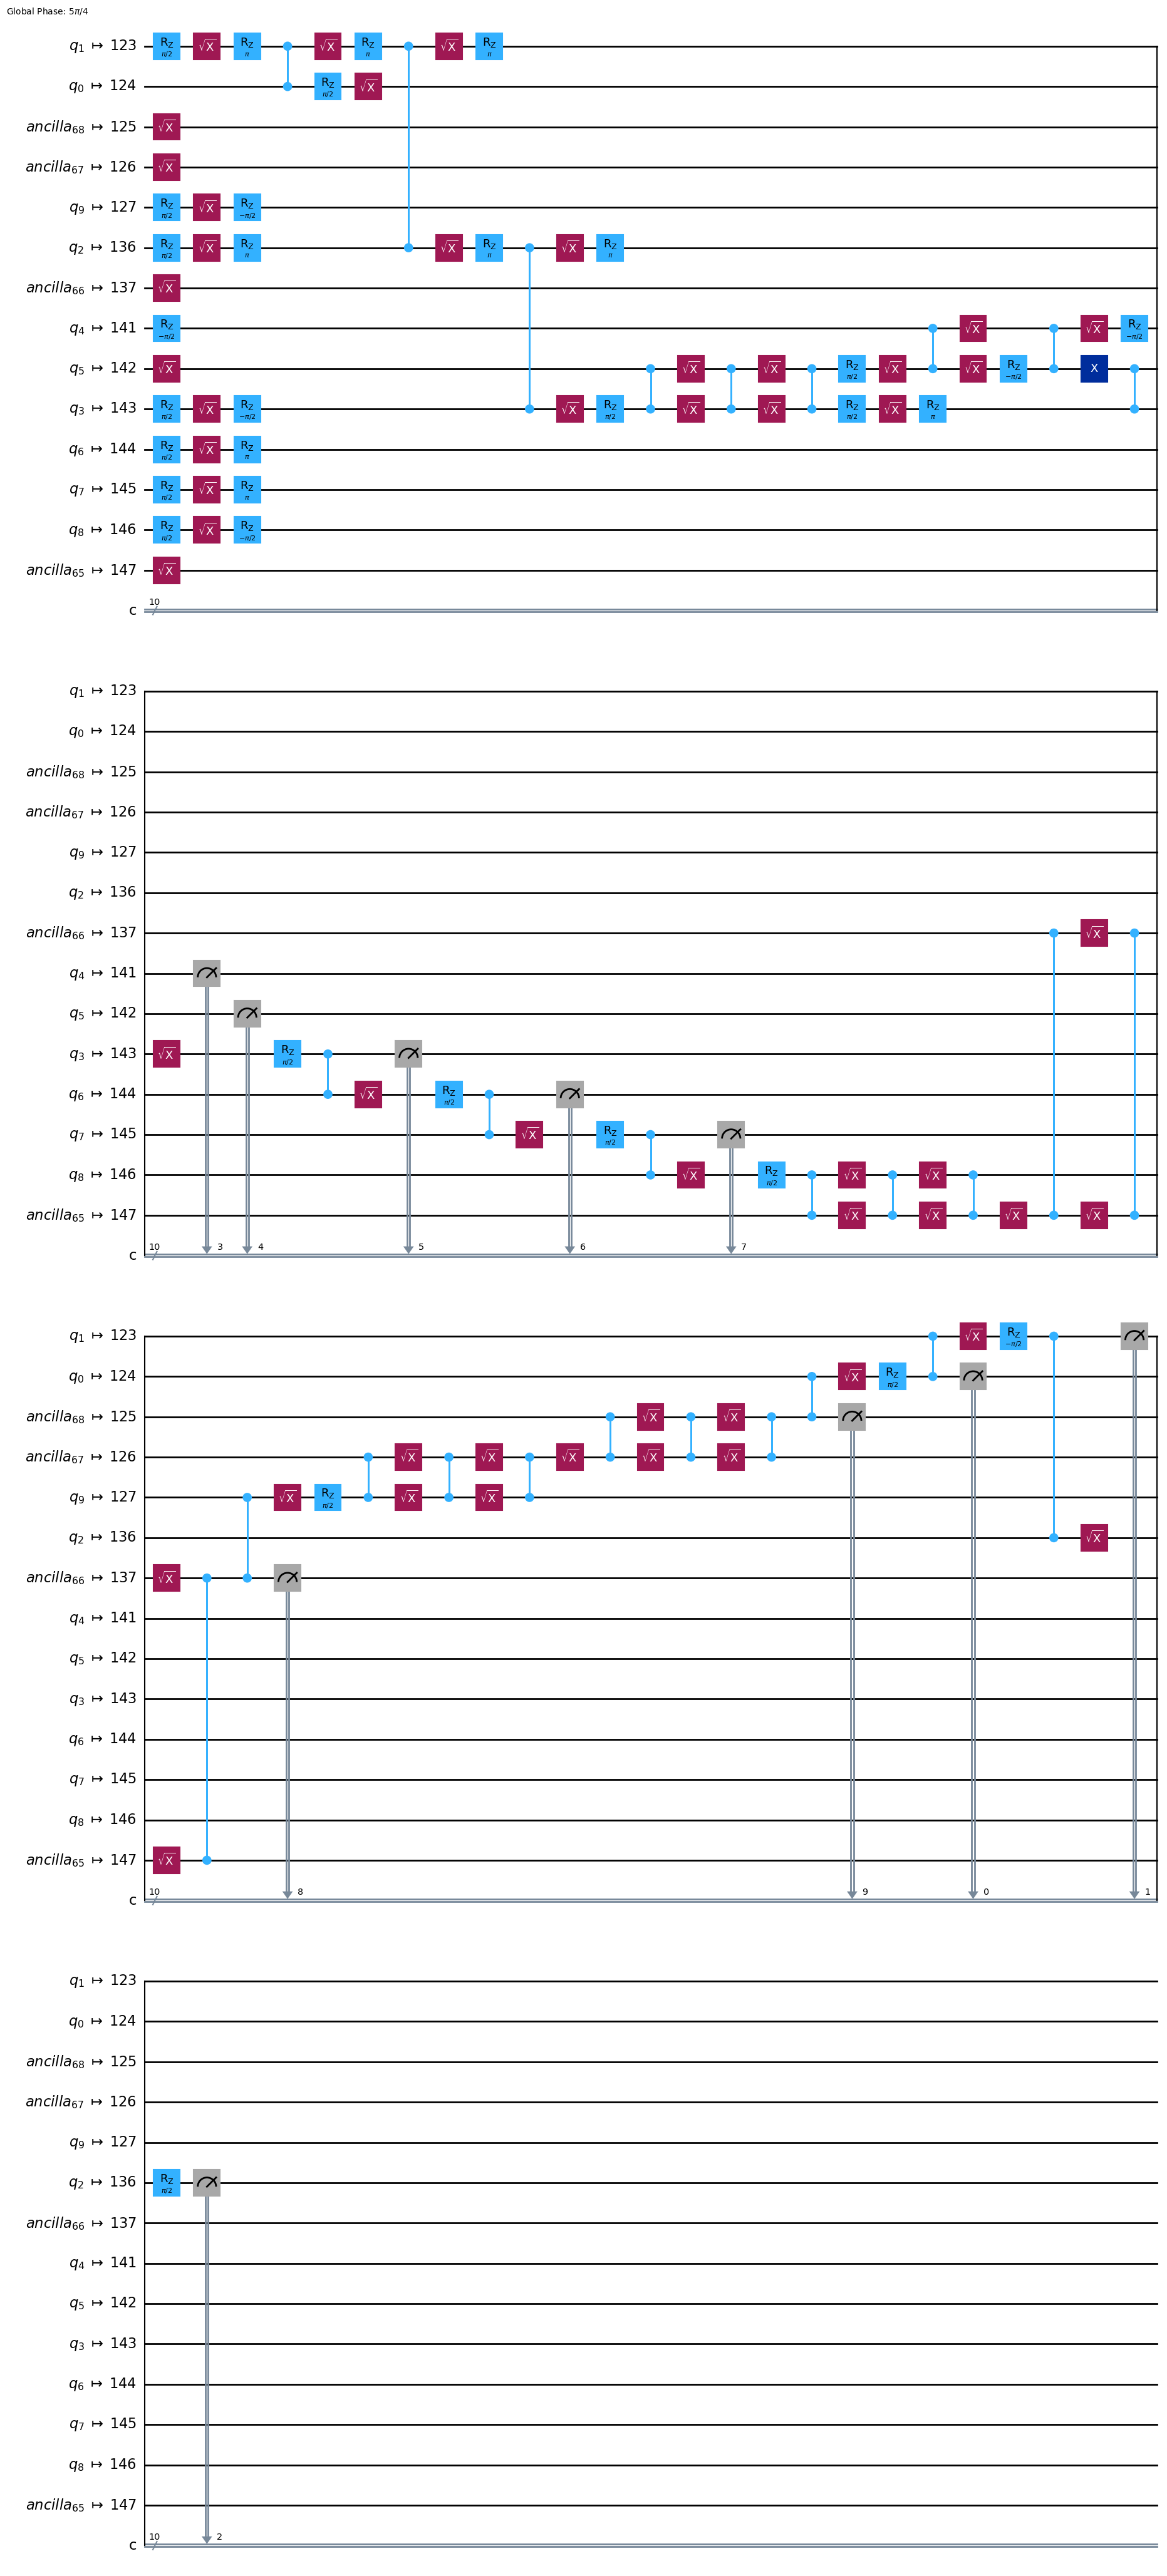

In [7]:
from qiskit_ibm_runtime.fake_provider import FakeFez, FakeTorino, FakeMarrakesh, FakePerth
from qiskit_ibm_runtime import SamplerV2 as Sampler
from qiskit import transpile

#Testing first with a simulator, then with a real backend
backend = FakeFez()

transpiled_circuit = transpile(qc, backend)
transpiled_circuit.draw("mpl")

In [8]:
sampler = Sampler(mode=backend)

experiment_errors = []

for _ in range(50):
    job = sampler.run([transpiled_circuit], shots=1024)
    counts = job.result()[0].join_data().get_counts()

    acc_sum = 0
    for state, count in counts.items():
        if state != "0000000111":
            acc_sum += count
    error = acc_sum / 1024
    experiment_errors.append(error)

print("Average error over 50 runs (Qiskit transpiler):", sum(experiment_errors) / len(experiment_errors))
print("Errors for each run:", experiment_errors)

Average error over 50 runs (Qiskit transpiler): 0.12734375
Errors for each run: [0.111328125, 0.1240234375, 0.1376953125, 0.140625, 0.15234375, 0.1259765625, 0.1318359375, 0.125, 0.130859375, 0.1513671875, 0.12890625, 0.142578125, 0.1044921875, 0.1240234375, 0.13671875, 0.12890625, 0.1201171875, 0.123046875, 0.1318359375, 0.1171875, 0.111328125, 0.1123046875, 0.1142578125, 0.119140625, 0.1220703125, 0.1259765625, 0.1337890625, 0.130859375, 0.1455078125, 0.142578125, 0.125, 0.1376953125, 0.1279296875, 0.11328125, 0.1142578125, 0.0966796875, 0.1328125, 0.1181640625, 0.1318359375, 0.1181640625, 0.134765625, 0.111328125, 0.1435546875, 0.126953125, 0.119140625, 0.13671875, 0.1259765625, 0.138671875, 0.125, 0.142578125]


# REAL QUANTUM HARDWARE
## We run each circuit 10 times with the custom transpiler and 10 times with the Qiskit transpiler

In [9]:
from qiskit_ibm_runtime.fake_provider import FakeFez, FakeTorino, FakeMarrakesh, FakePerth
from qiskit_ibm_runtime import SamplerV2 as Sampler

from qiskit_ibm_runtime import QiskitRuntimeService

service = QiskitRuntimeService()

# See all available backends
for b in service.backends():
    print(b.name, b.num_qubits, b.status().pending_jobs)

ibm_fez 156 0
ibm_marrakesh 156 0
ibm_kingston 156 0


In [10]:
backend = service.backend("ibm_fez")
print(f"Running on: {backend.name} ({backend.num_qubits} qubits)")

from QiskitTranspiler.transpiler.transpile import transpile

transpiled_circuit = transpile(qc, backend)
# transpiled_circuit.draw("mpl")

Running on: ibm_fez (156 qubits)
[BasisTranslator] Warning: Found a built-in equivalence table that covers the provided custom_basis. Using 'heron'


In [11]:
sampler = Sampler(mode=backend)
sampler.options.default_shots = 1024

for i in range(10):
    job = sampler.run([transpiled_circuit])
    print(f"Job ID: {job.job_id()}")

Job ID: d7ebrth5a5qc73dqp320
Job ID: d7ebrtu5nvhs73a6ivhg
Job ID: d7ebru15a5qc73dqp330
Job ID: d7ebru95a5qc73dqp33g
Job ID: d7ebrujklj2c73f2j9t0
Job ID: d7ebrur0g7hs73dsr4v0
Job ID: d7ebrv15a5qc73dqp35g
Job ID: d7ebrvb0g7hs73dsr50g
Job ID: d7ebrvh5a5qc73dqp37g
Job ID: d7ebrvp5a5qc73dqp390


In [13]:
job_ids = [
    "d7ebrth5a5qc73dqp320",
    "d7ebrtu5nvhs73a6ivhg",
    "d7ebru15a5qc73dqp330",
    "d7ebru95a5qc73dqp33g",
    "d7ebrujklj2c73f2j9t0",
    "d7ebrur0g7hs73dsr4v0",
    "d7ebrv15a5qc73dqp35g",
    "d7ebrvb0g7hs73dsr50g",
    "d7ebrvh5a5qc73dqp37g",
    "d7ebrvp5a5qc73dqp390",
]

experiment_errors = []

for job_id in job_ids:
    job = service.job(job_id)
    counts = job.result()[0].join_data().get_counts()

    acc_sum = 0
    for state, count in counts.items():
        if state != "0000000111":
            acc_sum += count
    error = acc_sum / 1024
    experiment_errors.append(error)
    print(f"Job {job_id}: error = {error:.4f}")

print("\nAverage error over runs:", sum(experiment_errors) / len(experiment_errors))
# print("Errors for each run:", experiment_errors)

Job d7ebrth5a5qc73dqp320: error = 0.3281
Job d7ebrtu5nvhs73a6ivhg: error = 0.3242
Job d7ebru15a5qc73dqp330: error = 0.3174
Job d7ebru95a5qc73dqp33g: error = 0.3281
Job d7ebrujklj2c73f2j9t0: error = 0.3086
Job d7ebrur0g7hs73dsr4v0: error = 0.3398
Job d7ebrv15a5qc73dqp35g: error = 0.3281
Job d7ebrvb0g7hs73dsr50g: error = 0.3047
Job d7ebrvh5a5qc73dqp37g: error = 0.3213
Job d7ebrvp5a5qc73dqp390: error = 0.3145

Average error over runs: 0.321484375


Running on: ibm_fez (156 qubits)


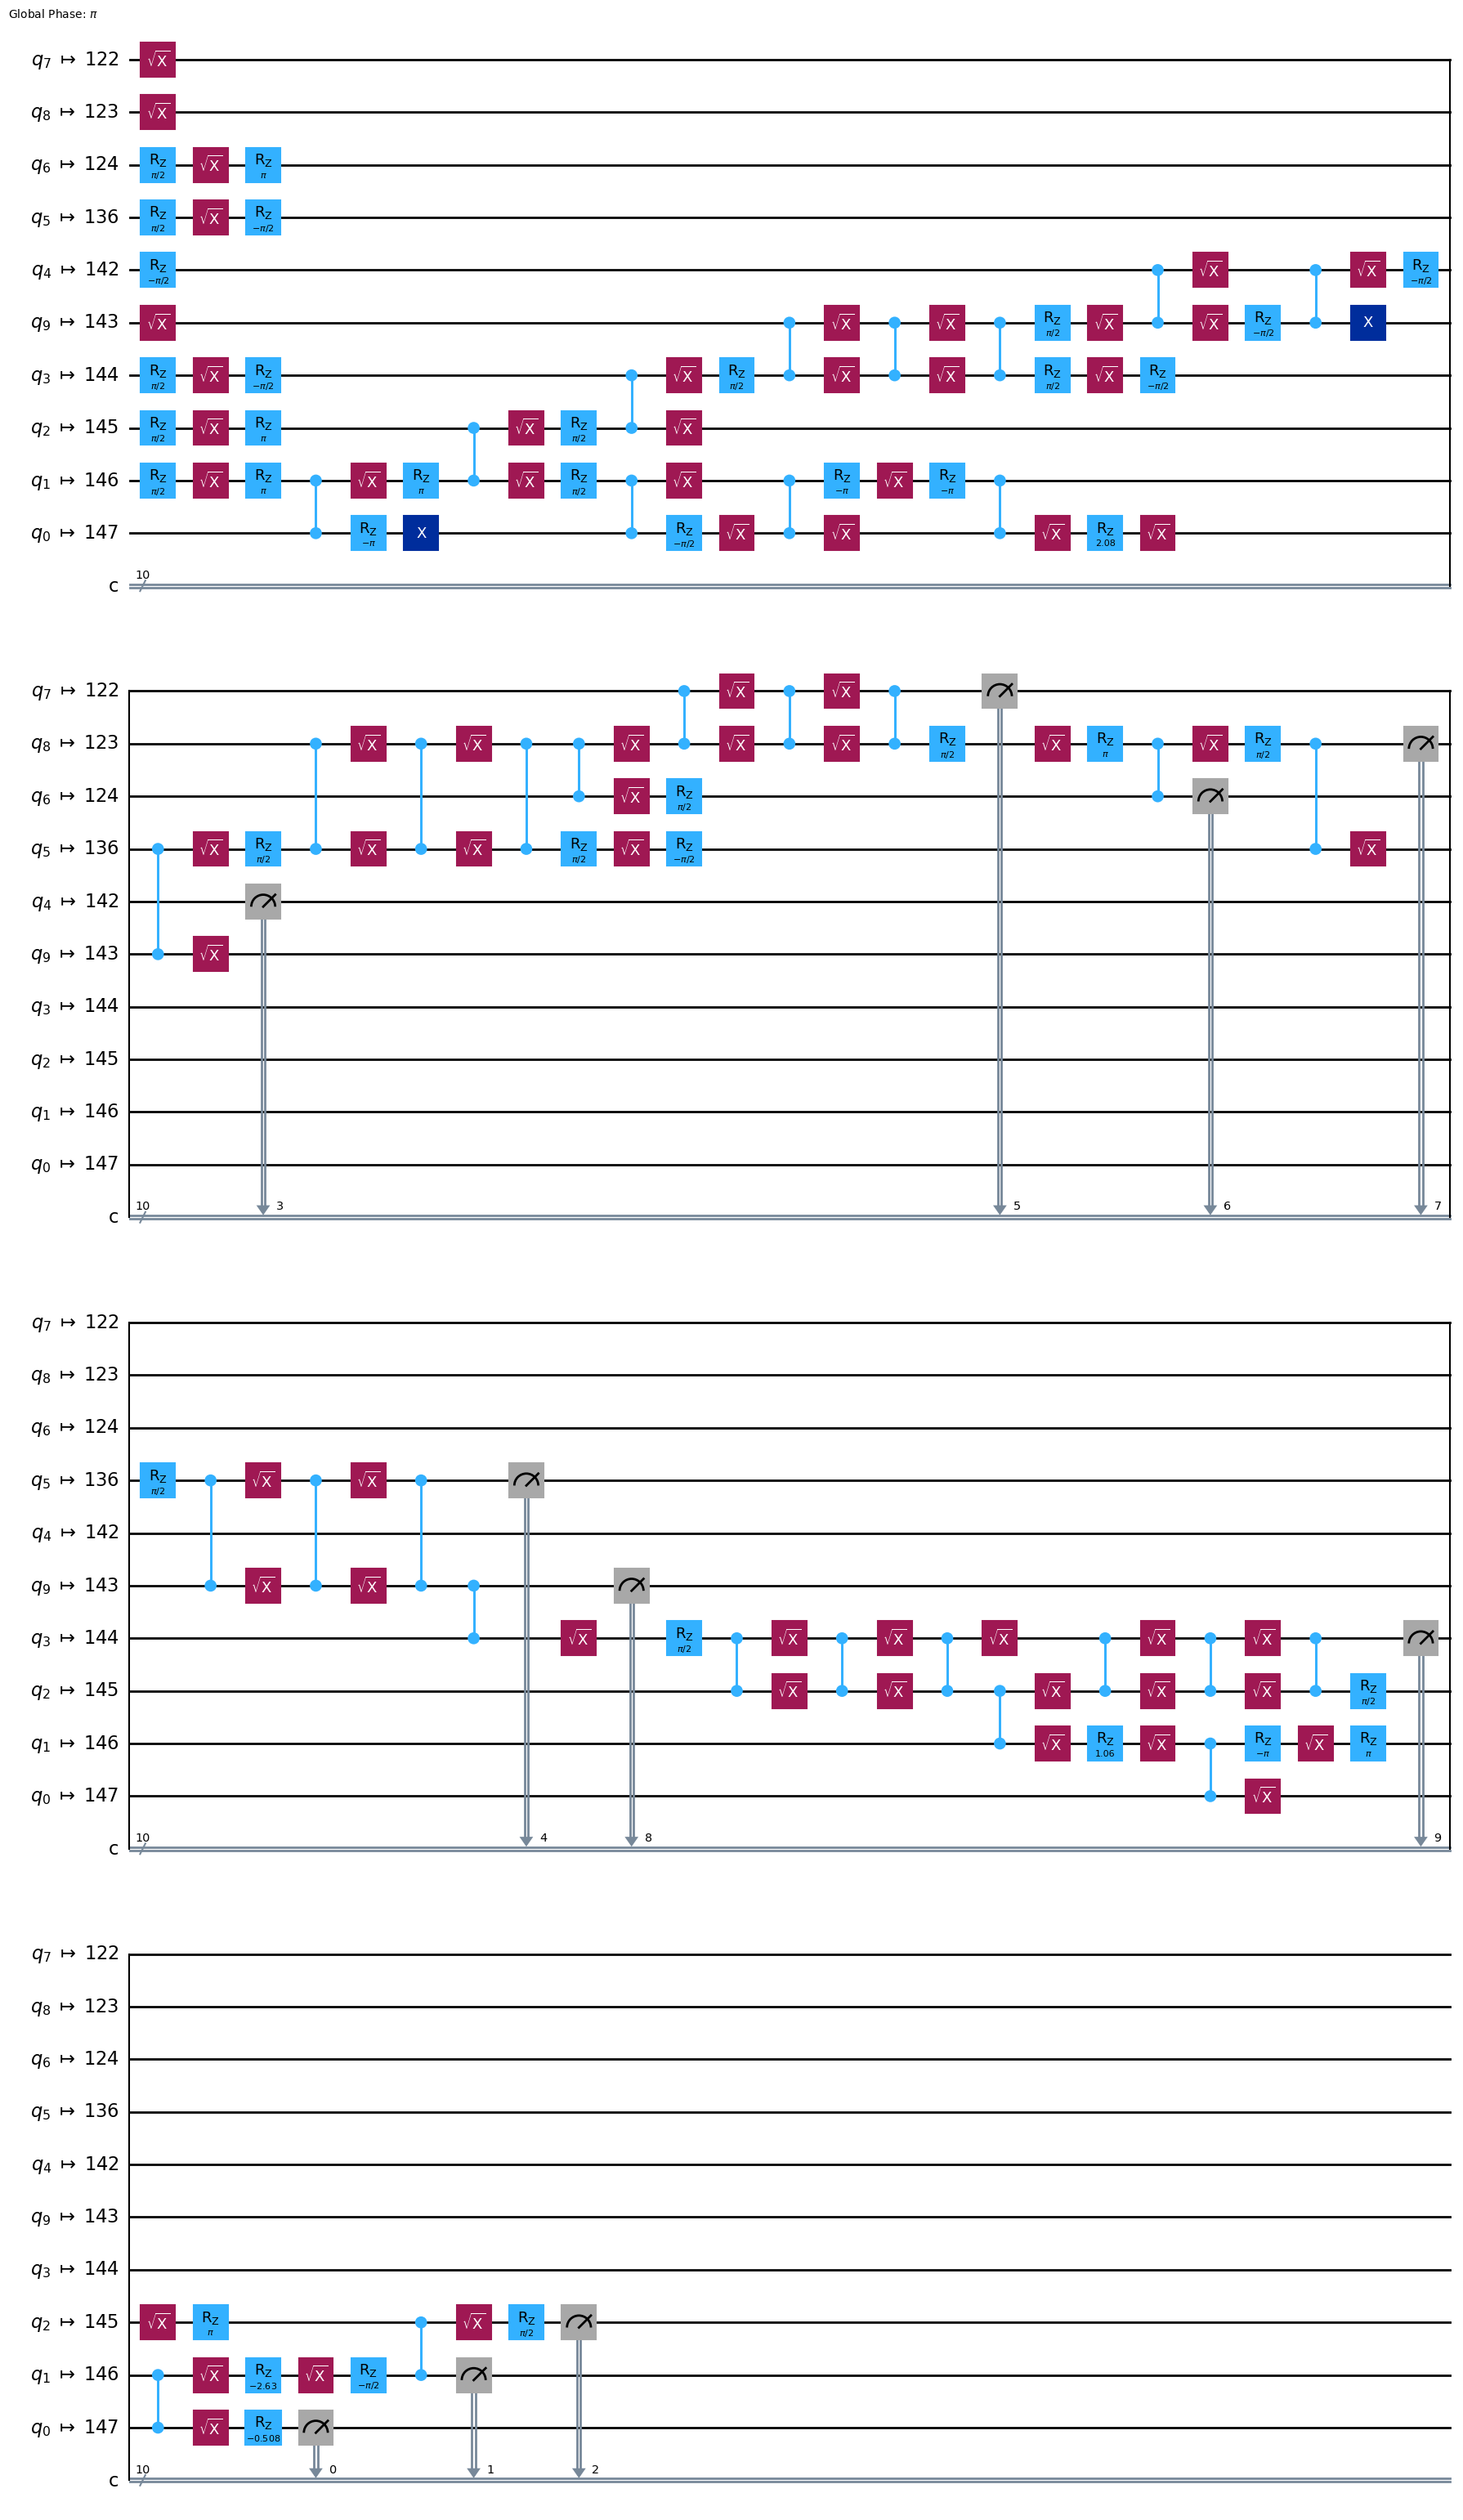

In [14]:
backend = service.backend("ibm_fez")
print(f"Running on: {backend.name} ({backend.num_qubits} qubits)")

from qiskit import transpile

transpiled_circuit = transpile(qc, backend)
transpiled_circuit.draw("mpl")
# qc.draw("mpl")

In [15]:
sampler = Sampler(mode=backend)
sampler.options.default_shots = 1024

for i in range(10):
    job = sampler.run([transpiled_circuit])
    print(f"Job ID: {job.job_id()}")

Job ID: d7ebvpr0g7hs73dsr8t0
Job ID: d7ebvq3klj2c73f2jdn0
Job ID: d7ebvq95a5qc73dqp7dg
Job ID: d7ebvqm5nvhs73a6j3ig
Job ID: d7ebvqr0g7hs73dsr8v0
Job ID: d7ebvr65nvhs73a6j3j0
Job ID: d7ebvr95a5qc73dqp7fg
Job ID: d7ebvrj0g7hs73dsr900
Job ID: d7ebvrh5a5qc73dqp7gg
Job ID: d7ebvrp5a5qc73dqp7h0


In [16]:
job_ids = [
    "d7ebvpr0g7hs73dsr8t0",
    "d7ebvq3klj2c73f2jdn0",
    "d7ebvq95a5qc73dqp7dg",
    "d7ebvqm5nvhs73a6j3ig",
    "d7ebvqr0g7hs73dsr8v0",
    "d7ebvr65nvhs73a6j3j0",
    "d7ebvr95a5qc73dqp7fg",
    "d7ebvrj0g7hs73dsr900",
    "d7ebvrh5a5qc73dqp7gg",
    "d7ebvrp5a5qc73dqp7h0",
]

experiment_errors = []

for job_id in job_ids:
    job = service.job(job_id)
    counts = job.result()[0].join_data().get_counts()

    acc_sum = 0
    for state, count in counts.items():
        if state != "0000000111":
            acc_sum += count
    error = acc_sum / 1024
    experiment_errors.append(error)
    print(f"Job {job_id}: error = {error:.4f}")

print("\nAverage error over runs:", sum(experiment_errors) / len(experiment_errors))
# print("Errors for each run:", experiment_errors)

Job d7ebvpr0g7hs73dsr8t0: error = 0.2412
Job d7ebvq3klj2c73f2jdn0: error = 0.2646
Job d7ebvq95a5qc73dqp7dg: error = 0.2705
Job d7ebvqm5nvhs73a6j3ig: error = 0.2646
Job d7ebvqr0g7hs73dsr8v0: error = 0.2646
Job d7ebvr65nvhs73a6j3j0: error = 0.2764
Job d7ebvr95a5qc73dqp7fg: error = 0.2324
Job d7ebvrj0g7hs73dsr900: error = 0.2607
Job d7ebvrh5a5qc73dqp7gg: error = 0.2432
Job d7ebvrp5a5qc73dqp7h0: error = 0.2529

Average error over runs: 0.25712890625
